# Reproducing the move-level Table 4 experiments

This notebook reproduces the move-level Table 4 experiments by training the three reported feed-forward detectors: Allie embeddings, nine handcrafted features, and their concatenation. Models are trained on paired ChessFraud-Synth positions and transferred unchanged to the controlled ChessFraud tournament, while the public Allie embedding bundle demonstrates reproducible artifact acquisition and row alignment.

## Protocol

The dataset revision, eight-source assistance mixture, preprocessing boundary, architecture, optimizer, scheduler, early stopping rule, random seed, and decision threshold are fixed. Embedding rows are resolved through explicit one-to-one joins rather than assumed from Hugging Face row order. Install the shared runtime from `requirements/tutorials.txt` before execution.

In [1]:
from __future__ import annotations

import json
import os
import sys
from dataclasses import asdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from datasets import load_dataset
from IPython.display import display

REPO_ROOT = next(
    parent
    for parent in (Path.cwd(), *Path.cwd().parents)
    if (parent / "experiments" / "move_level").is_dir()
)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from experiments.move_level.detection import (
    CLASSICAL_ASSISTANCE_SOURCES,
    MoveLevelTrainConfig,
    build_observed_move_inputs,
    build_move_level_pairs,
    compute_detection_metrics,
    fit_move_level_preprocessor,
    predict_move_level_detector,
    train_move_level_detector,
)
from experiments.move_level.allie_embeddings import (
    PUBLIC_DATASET_REVISION,
    resolve_allie_embedding_root,
)

SEED = 42
DATASET_ID = "artemlepin/chess-fraud"
DATASET_REVISION = PUBLIC_DATASET_REVISION
ALLIE_EMBEDDING_ROOT = resolve_allie_embedding_root(revision=DATASET_REVISION)
SYNTH_EMBEDDINGS = ALLIE_EMBEDDING_ROOT / "synth"
SYNTH_ROW_INDEX = ALLIE_EMBEDDING_ROOT / "synth/row_index.parquet"
TOURNAMENT_EMBEDDINGS = ALLIE_EMBEDDING_ROOT / "tournament/embs_allie_2500.npz"
TOURNAMENT_ROW_INDEX = ALLIE_EMBEDDING_ROOT / "tournament/row_index.parquet"

def configured_path(env_name: str, default: str) -> Path:
    return Path(os.environ.get(env_name, str(REPO_ROOT / default)))

OUTPUT_DIR = configured_path(
    "CHESSFRAUD_DETECTION_OUTPUT_DIR", "reports/move_level/detection_reproduction"
)

assert torch.cuda.is_available(), "This full-batch experiment requires CUDA."
DEVICE = torch.device("cuda")
GPU_NAME = torch.cuda.get_device_name(0)
assert "A100" in GPU_NAME, f"Expected an NVIDIA A100, found {GPU_NAME}."
print({"dataset_revision": DATASET_REVISION, "device": GPU_NAME, "seed": SEED})

{'dataset_revision': 'bd2804f268bf07c306217929db9b8dda5803392b', 'device': 'NVIDIA A100-SXM4-80GB', 'seed': 42}


In [2]:
# Join the pinned Synth rows to the public embedding row index.
synth_dataset = load_dataset(
    DATASET_ID, "chess_fraud_synth", revision=DATASET_REVISION
)
synth_parts = []
for split_name in ("train", "test"):
    part = synth_dataset[split_name].to_pandas()
    part["hf_split"] = split_name
    synth_parts.append(part)
synth_hf = pd.concat(synth_parts, ignore_index=True)
synth_hf = synth_hf.loc[synth_hf["is_used"]].copy()

synth_index = pd.read_parquet(SYNTH_ROW_INDEX).rename(
    columns={"move_thinking_time": "index_move_thinking_time"}
)
synth_keys = ["player_id", "game_id", "half_move", "move_player"]
assert not synth_hf.duplicated(synth_keys).any()
assert not synth_index.duplicated(synth_keys).any()
synth = synth_index.merge(
    synth_hf, on=synth_keys, how="left", validate="one_to_one", indicator=True
)
assert synth["_merge"].eq("both").all()
hf_time_present = synth["move_thinking_time"].notna()
assert np.allclose(
    synth.loc[hf_time_present, "move_thinking_time"],
    synth.loc[hf_time_present, "index_move_thinking_time"],
    rtol=0.0,
    atol=0.0,
)
assert np.isfinite(synth["index_move_thinking_time"]).all()
thinking_time_audit = pd.DataFrame([{
    "HF finite": int(hf_time_present.sum()),
    "HF null": int((~hf_time_present).sum()),
    "row-index finite": int(np.isfinite(synth["index_move_thinking_time"]).sum()),
}])
synth["move_thinking_time"] = synth["index_move_thinking_time"]
synth = synth.drop(columns=["_merge", "index_move_thinking_time"])
synth = synth.sort_values("embedding_row").reset_index(drop=True)
assert len(synth) == 417_207
assert np.array_equal(synth["embedding_row"].to_numpy(), np.arange(len(synth)))

synth_embeddings = {
    "move_player": np.load(SYNTH_EMBEDDINGS / "move_uci.npy", mmap_mode="r"),
    **{
        f"move_{source}": np.load(
            SYNTH_EMBEDDINGS / f"move_{source}.npy", mmap_mode="r"
        )
        for source in CLASSICAL_ASSISTANCE_SOURCES
    },
}
synth_shape_audit = pd.DataFrame(
    [
        {"array": name, "rows": array.shape[0], "dimensions": array.shape[1], "dtype": str(array.dtype)}
        for name, array in synth_embeddings.items()
    ]
)
assert synth_shape_audit[["rows", "dimensions"]].eq([len(synth), 1024]).all().all()
display(thinking_time_audit)
display(synth_shape_audit)

,HF finite,HF null,row-index finite
0,417155,52,417207


,array,rows,dimensions,dtype
0,move_player,417207,1024,float16
1,move_stockfish_1,417207,1024,float16
2,move_stockfish_5,417207,1024,float16
3,move_stockfish_9,417207,1024,float16
4,move_stockfish_11,417207,1024,float16
5,move_stockfish_15,417207,1024,float16
6,move_lc0_1,417207,1024,float16
7,move_lc0_10,417207,1024,float16
8,move_lc0_100,417207,1024,float16


In [3]:
# Join tournament rows to the public 77,020-row embedding index.
tournament = load_dataset(
    DATASET_ID, "chess_fraud", split="full", revision=DATASET_REVISION
).to_pandas()
tournament_index = pd.read_parquet(TOURNAMENT_ROW_INDEX)
tournament_keys = ["game_id", "player_id", "half_move", "move_player"]
assert not tournament.duplicated(tournament_keys).any()
assert not tournament_index.duplicated(tournament_keys).any()
tournament = tournament.merge(
    tournament_index[tournament_keys + ["embedding_row"]],
    on=tournament_keys,
    how="left",
    validate="one_to_one",
    indicator=True,
)
assert len(tournament) == 38_510
assert tournament["_merge"].eq("both").all()
tournament = tournament.drop(columns="_merge")
tournament = tournament.loc[tournament["is_used"]].reset_index(drop=True)
assert tournament["embedding_row"].is_unique

tournament_archive = np.load(TOURNAMENT_EMBEDDINGS, mmap_mode="r")
tournament_embeddings = {"move_player": tournament_archive["move_uci"]}
tournament_index_audit = pd.DataFrame(
    [{
        "hf_rows": len(tournament),
        "embedding_rows": tournament_embeddings["move_player"].shape[0],
        "embedding_dimensions": tournament_embeddings["move_player"].shape[1],
        "index_min": int(tournament["embedding_row"].min()),
        "index_max": int(tournament["embedding_row"].max()),
        "index_unique": int(tournament["embedding_row"].nunique()),
        "index_monotonic": bool(tournament["embedding_row"].is_monotonic_increasing),
    }]
)
display(tournament_index_audit)

,hf_rows,embedding_rows,embedding_dimensions,index_min,index_max,index_unique,index_monotonic
0,28410,77020,1024,20,77019,28410,False


In [4]:
# Create a deterministic player-disjoint validation split inside the HF training split.
rng = np.random.default_rng(SEED)
train_pool = synth.loc[synth["hf_split"].eq("train")]
player_bins = train_pool[["player_id", "rating_bin"]].drop_duplicates()
assert not player_bins["player_id"].duplicated().any()
validation_players = set()
for rating_bin in sorted(player_bins["rating_bin"].unique()):
    players = np.sort(
        player_bins.loc[player_bins["rating_bin"].eq(rating_bin), "player_id"].to_numpy()
    )
    rng.shuffle(players)
    validation_count = max(1, int(round(0.1 * len(players))))
    validation_players.update(players[:validation_count].tolist())

is_hf_train = synth["hf_split"].eq("train").to_numpy()
is_validation_player = synth["player_id"].isin(validation_players).to_numpy()
train_index = np.flatnonzero(is_hf_train & ~is_validation_player)
validation_index = np.flatnonzero(is_hf_train & is_validation_player)
synth_test_index = np.flatnonzero(synth["hf_split"].eq("test").to_numpy())
assert set(synth.iloc[train_index]["player_id"]).isdisjoint(
    set(synth.iloc[validation_index]["player_id"])
)
preprocessor = fit_move_level_preprocessor(synth.iloc[train_index])
split_audit = pd.DataFrame(
    {"split": ["train", "validation", "Synth test"],
     "positions": [len(train_index), len(validation_index), len(synth_test_index)]}
)
display(split_audit)
print(asdict(preprocessor))

,split,positions
0,train,301304
1,validation,32836
2,Synth test,83067


{'player_elo_mean': 1601.7595285824284, 'player_elo_std': 361.2935581205476, 'opponent_elo_mean': 1600.7722366779067, 'opponent_elo_std': 360.41776558220056, 'thinking_time_mean': 1.4649189656283754, 'thinking_time_std': 0.7840747931015782, 'centipawn_loss_mean': 39.3429426758357, 'centipawn_loss_std': 129.92786102226444}


In [5]:
# Build the paired Synth candidates and the observed tournament candidates.
synth_pairs = build_move_level_pairs(
    synth,
    synth_embeddings,
    embedding_index_col="embedding_row",
    preprocessor=preprocessor,
)
tournament_observed = build_observed_move_inputs(
    tournament,
    tournament_embeddings,
    preprocessor,
    embedding_index_column="embedding_row",
)
assert np.array_equal(synth_pairs.fair.row_ids, synth_pairs.assistance.row_ids)
assert np.array_equal(synth_pairs.fair.row_ids, synth.index.to_numpy())

probe_records = []
for position in (0, len(synth) // 2, len(synth) - 1):
    row = synth.iloc[position]
    source = synth_pairs.assistance_sources[position]
    probe_records.append({
        "position": position,
        "key": (row["player_id"], row["game_id"], int(row["half_move"]), row["move_player"]),
        "embedding_row": int(row["embedding_row"]),
        "source": source,
        "candidate_move": row[f"move_{source}"],
        "candidate_eval": float(row[f"eval_{source}"]),
        "embedding_head": np.round(synth_pairs.assistance.embeddings[position, :3], 5).tolist(),
    })
display(pd.DataFrame(probe_records))

,position,key,embedding_row,source,candidate_move,candidate_eval,embedding_head
0,0,"(A3_LTC, 9EayTTaI, 21, a2a4)",0,stockfish_1,b2b4,13.0,"[0.14611999690532684, -0.044860001653432846, -..."
1,208603,"(Valerian2019, Zt1NcnvW, 35, h4g6)",208603,stockfish_15,h4g6,79.0,"[-0.11333999782800674, 0.1309799998998642, -0...."
2,417206,"(zvolk966, xTNCUcXQ, 62, f4e3)",417206,stockfish_5,f4h4,-607.0,"[0.00989999994635582, -0.035339999943971634, -..."


In [6]:
VARIANTS = {
    "FFN Allie": "allie",
    "FFN Features": "features",
    "FFN Allie + Features": "combined",
}

def candidate_matrix(candidates, variant: str, index: np.ndarray | None = None) -> np.ndarray:
    rows = slice(None) if index is None else index
    if variant == "allie":
        return candidates.embeddings[rows]
    if variant == "features":
        return candidates.features[rows]
    return np.concatenate(
        [candidates.embeddings[rows], candidates.features[rows]], axis=1
    ).astype(np.float32, copy=False)

def paired_matrix(index: np.ndarray, variant: str) -> tuple[np.ndarray, np.ndarray]:
    fair = candidate_matrix(synth_pairs.fair, variant, index)
    assistance = candidate_matrix(synth_pairs.assistance, variant, index)
    inputs = np.concatenate([fair, assistance], axis=0).astype(np.float32, copy=False)
    labels = np.concatenate([
        np.zeros(len(index), dtype=np.int64),
        np.ones(len(index), dtype=np.int64),
    ])
    return inputs, labels

shape_audit = []
for model_name, variant in VARIANTS.items():
    shape_audit.append({
        "model": model_name,
        "Synth dimensions": candidate_matrix(synth_pairs.fair, variant).shape[1],
        "Tournament dimensions": candidate_matrix(tournament_observed, variant).shape[1],
    })
shape_audit = pd.DataFrame(shape_audit)
assert shape_audit["Synth dimensions"].tolist() == [1024, 9, 1033]
assert shape_audit["Tournament dimensions"].tolist() == [1024, 9, 1033]
display(shape_audit)

,model,Synth dimensions,Tournament dimensions
0,FFN Allie,1024,1024
1,FFN Features,9,9
2,FFN Allie + Features,1033,1033


In [7]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
TRAIN_CONFIG = MoveLevelTrainConfig()
models = {}
diagnostics = {}

for model_name, variant in VARIANTS.items():
    train_inputs, train_labels = paired_matrix(train_index, variant)
    validation_inputs, validation_labels = paired_matrix(validation_index, variant)
    model = train_move_level_detector(
        train_inputs,
        train_labels,
        validation_inputs,
        validation_labels,
        config=TRAIN_CONFIG,
        device=DEVICE,
    )
    models[model_name] = model
    diagnostics[model_name] = pd.DataFrame(model.training_history)
    artifact_name = variant.replace("combined", "allie_features")
    torch.save(model.state_dict(), OUTPUT_DIR / f"{artifact_name}.pt")
    del train_inputs, train_labels, validation_inputs, validation_labels
    torch.cuda.empty_cache()

training_summary = pd.DataFrame([
    {"model": name,
     "best_epoch": int(model.best_epoch),
     "best_validation_macro_f1": float(model.best_validation_macro_f1)}
    for name, model in models.items()
])
training_summary.to_csv(OUTPUT_DIR / "training_summary.csv", index=False)
(OUTPUT_DIR / "run_config.json").write_text(json.dumps({
    "dataset_id": DATASET_ID,
    "dataset_revision": DATASET_REVISION,
    "sources": list(CLASSICAL_ASSISTANCE_SOURCES),
    "train_config": asdict(TRAIN_CONFIG),
    "preprocessor": asdict(preprocessor),
}, indent=2))
display(training_summary)

,model,best_epoch,best_validation_macro_f1
0,FFN Allie,212,0.575318
1,FFN Features,16,0.633554
2,FFN Allie + Features,169,0.665114


In [8]:
result_rows = []
for model_name, variant in VARIANTS.items():
    synth_inputs, synth_labels = paired_matrix(synth_test_index, variant)
    synth_predictions = predict_move_level_detector(models[model_name], synth_inputs, device=DEVICE)
    synth_metrics = compute_detection_metrics(synth_labels, synth_predictions)
    result_rows.append({"dataset": "Synth", "model": model_name, **synth_metrics})

    tournament_inputs = candidate_matrix(tournament_observed, variant)
    tournament_labels = tournament["is_cheating_move"].to_numpy(dtype=np.int64)
    tournament_predictions = predict_move_level_detector(
        models[model_name], tournament_inputs, device=DEVICE
    )
    tournament_metrics = compute_detection_metrics(
        tournament_labels, tournament_predictions
    )
    result_rows.append({"dataset": "Tournament", "model": model_name, **tournament_metrics})
    del synth_inputs, synth_labels, tournament_inputs
    torch.cuda.empty_cache()

reproduced = pd.DataFrame(result_rows)
reproduced.to_csv(OUTPUT_DIR / "move_level_metrics.csv", index=False)

In [9]:
paper_rows = [
    ("Synth", "FFN Allie", 0.60, 0.55, 0.57),
    ("Tournament", "FFN Allie", 0.59, 0.52, 0.53),
    ("Synth", "FFN Features", 0.69, 0.57, 0.63),
    ("Tournament", "FFN Features", 0.50, 0.72, 0.55),
    ("Synth", "FFN Allie + Features", 0.66, 0.75, 0.71),
    ("Tournament", "FFN Allie + Features", 0.62, 0.59, 0.59),
]
paper = pd.DataFrame(
    paper_rows,
    columns=["dataset", "model", "paper_specificity", "paper_recall", "paper_macro_f1"],
)
comparison = reproduced.merge(paper, on=["dataset", "model"], validate="one_to_one")
comparison = comparison.rename(columns={
    "specificity": "reproduced_specificity",
    "recall": "reproduced_recall",
    "macro_f1": "reproduced_macro_f1",
})
display(comparison.round(3))

,dataset,model,reproduced_specificity,reproduced_recall,reproduced_macro_f1,paper_specificity,paper_recall,paper_macro_f1
0,Synth,FFN Allie,0.586,0.564,0.575,0.60,0.55,0.57
1,Tournament,FFN Allie,0.572,0.543,0.534,0.59,0.52,0.53
2,Synth,FFN Features,0.526,0.753,0.635,0.69,0.57,0.63
3,Tournament,FFN Features,0.485,0.681,0.531,0.50,0.72,0.55
4,Synth,FFN Allie + Features,0.642,0.687,0.664,0.66,0.75,0.71
5,Tournament,FFN Allie + Features,0.620,0.589,0.580,0.62,0.59,0.59


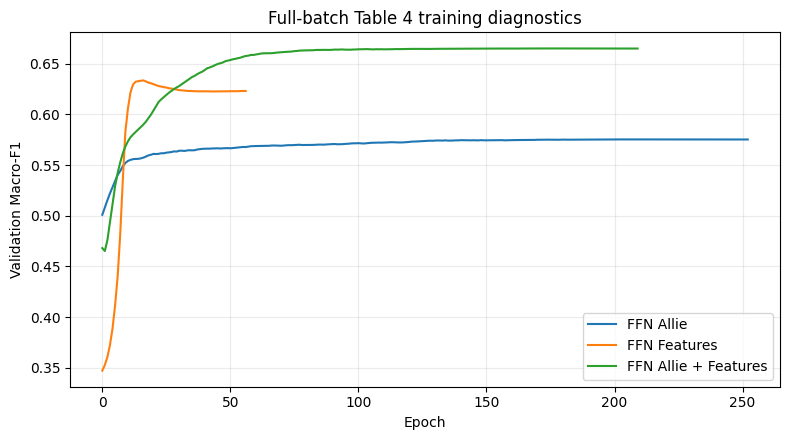

In [10]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for model_name, history in diagnostics.items():
    ax.plot(history["epoch"], history["validation_macro_f1"], label=model_name)
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation Macro-F1")
ax.set_title("Full-batch move-level detector training diagnostics")
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
plt.show()

The saved run metadata records the immutable dataset revision, source order, preprocessing statistics, and published training configuration. Tournament metrics use the same fitted preprocessing, model weights, and fixed 0.5 threshold as the Synth evaluation.